In [5]:
# auto reload modules
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from globalVars import *
from load_data_pickles import *
from analysis_functions import mean_and_interquartile
from plotting_variables import MINI_SIZE

print('data length = ',N) # data length in a trial
print('primes = ',primes) # array([ 2,  3,  5,  7, 11, 13, 17, 19])
print('base freq = ',base_freq) # 0.05Hz
print('IX = ',IX) # index of stimulated freqs, array([ 4,  6, 10, 14, 22, 26, 34, 38])
print('freqs = ',freqs) # stimulated freqs
print('omegas = ',omegas) # 2*pi*freqs
print('T = ',T) # total time of a trial 40 seconds
print('t = ',t) # timestamps in a trial
print('fs = ',fs) # 60 Hz
print('sample_period (dt)= ',dt) # 1/ dt
print('xf = ',xf) # frequency domain x-axis, shape (N//2,)
print('s = ',s) # continuous, s = jw
print('z = ',z) # discrete, z = exp(jwT)
print('second order machine = ',soM) # second order machine at stimulated freqs
print('zero = ',zero) # function, 0th-order dynamics
print('first = ',first) # function, 1st-order dynamics
print('second = ',second) # function, 2nd-order dynamics

print('subject_num = ',subject_num)
print('condition_num (orders) = ',condition_num)
print('trial_num = ',trial_num)
print('trial_num of baseline = ',trial_num_base)
print('\n')

# interface transfer function parameters (subjects x trials x number of parameters)
print('0th-order interface parameters, G_parameters shape= ',G_parameters[0].shape)
print('1st-order interface parameters, G_parameters shape= ',G_parameters[1].shape)
print('2nd-order interface parameters, G_parameters shape= ',G_parameters[2].shape)
# print(G_parameters[0].shape,G_parameters[1].shape,G_parameters[2].shape) 
print('\n')

# freqeuncy domain signals
print('Interface transfer function, Gs shape=', Gs.shape) # interface transfer function (subjects x condition x trials x stim frequencies)
print('Human transfer function, Hs shape=',Hs.shape) # human transfer function (subjects x condition x trials x stim frequencies)
print('Disturbance signals, Ds shape=', Ds.shape) # disturbances (subjects x condition x trials x number of frequencies)
print('Human inputs signals, UHs shape=', UHs.shape) # human inputs (subjects x condition x trials x number of frequencies)
print('Interface inputs signals, UIs shape=', UGs.shape) # interface inputs (subjects x condition x trials x number of frequencies)
print('Output signals, Ys shape=', Ys.shape) # output (subjects x condition x trials x number of frequencies)
print('\n')
print('Baseline interface transfer function, Gs_base shape=', Gs_base.shape) # interface transfer function (subjects x trials x stim frequencies)
print('\n')

# time domain signals
print('time-domain disturbances, ds shape=', ds.shape) # disturbances (subjects x condition x trials x number of time points)
print('time-domain human inputs, uhs shape=', uhs.shape) # human inputs (subjects x condition x trials x number of time points)
print('time-domain interface inputs, ugs shape=', ugs.shape) # interface inputs (subjects x condition x trials x number of time points)
print('time-domain outputs, ys shape=', ys.shape) # output (subjects x condition x trials x number of time points)
print('time-domain MSE per trial, errors shape=',errors.shape) # errors (subjects x condition x trials) #np.sum(abs(outs)**2)
print('\n')

# baseline interfaces (I stars) for each condition
I_star_0 = Gs[0,0,0]
I_star_1 = Gs[0,1,0]
I_star_2 = Gs[0,2,0]
I_stars = [I_star_0,I_star_1,I_star_2]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
data length =  2400
primes =  [ 2  3  5  7 11 13 17 19]
base freq =  0.05
IX =  [ 4  6 10 14 22 26 34 38]
freqs =  [0.1  0.15 0.25 0.35 0.55 0.65 0.85 0.95]
omegas =  [0.62831853 0.9424778  1.57079633 2.19911486 3.45575192 4.08407045
 5.34070751 5.96902604]
T =  40
t =  [0.00000000e+00 1.66736140e-02 3.33472280e-02 ... 3.99666528e+01
 3.99833264e+01 4.00000000e+01]
fs =  60
sample_period (dt)=  0.016666666666666666
xf =  [0.0000e+00 2.5000e-02 5.0000e-02 ... 2.9925e+01 2.9950e+01 2.9975e+01]
s =  <function <lambda> at 0x1232da520>
z =  <function <lambda> at 0x1235c4e00>
second order machine =  [ 0.71461011-0.8032687j   0.33652234-0.98372476j -0.33237591-0.86073923j
 -0.6163471 -0.48027949j -0.55477368+0.01684599j -0.46273241+0.11912274j
 -0.31404983+0.19698778j -0.26054454+0.2069847j ]
zero =  <function zero at 0x123828360>
first =  <function first at 0x12783c900>
second =  <function second at 0x127

 0.100, p-value: 0.000
 0.150, p-value: 0.000
 0.250, p-value: 0.000
 0.350, p-value: 0.000
 0.550, p-value: 0.000
 0.650, p-value: 0.000
 0.850, p-value: 0.000
 0.950, p-value: 0.000


 0.100, p-value: 0.000
 0.150, p-value: 0.000
 0.250, p-value: 0.001
 0.350, p-value: 0.001
 0.550, p-value: 0.003
 0.650, p-value: 0.004
 0.850, p-value: 0.005
 0.950, p-value: 0.005


 0.100, p-value: 0.005
 0.150, p-value: 0.002
 0.250, p-value: 0.004
 0.350, p-value: 0.003
 0.550, p-value: 0.003
 0.650, p-value: 0.003
 0.850, p-value: 0.003
 0.950, p-value: 0.003




/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_44438/1039405620.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(freqs,quantile50,'-',marker = '.',color = 'black',label = 'baseline (fixed)',linestyle='--')


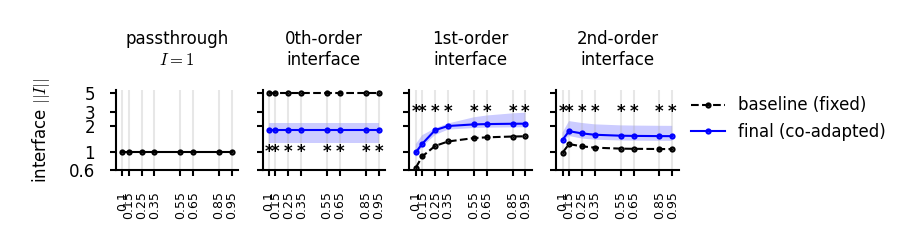

In [6]:
# interface I magnitude: I* (fixed) vs. co-adapted (final 3 trials)
xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
xlim = (0.05, 1.0)
fig,axs = plt.subplots(1,4,sharex=True,sharey=True,figsize=(3,0.75),dpi=300)

for cond, condition in enumerate(condition_orders):
    I_last_3_trials = np.mean(np.abs(Gs[:,cond,15:18,:]),axis = 1) # last 3 adaptive trials
    selected = np.concatenate((Gs[:,cond,:3], Gs[:,cond,-3:]), axis=1) # 6 fixed trials
    I_star = np.mean(np.abs(selected),axis = 1) # I*

    ax = axs[cond+1]
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(I_star, axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'black',label = 'baseline (fixed)',linestyle='--')
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'black',edgecolor='none')
    ax.set_title(str(condition)+'-order\ninterface')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(I_last_3_trials, axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'blue',label = 'final (co-adapted)')
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'blue',edgecolor='none')

    for f in range(len(freqs)):
        data1 = I_last_3_trials[:,f] # average across trials
        data2 = I_star[:,f] # average across trials
        statistic, p_value = stats.ttest_rel(data1, data2)
        print(f" {freqs[f]:.3f}, p-value: {p_value:.3f}")

        if p_value < 0.05:
            where_star = 1 if cond == 0 else 3
            ax.text(freqs[f], where_star, '*', ha='center', va='center', fontweight='bold')

    print('\n')

ax = axs[0]
I_base_trials = np.mean(np.abs(Gs_base),axis = 1)
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(I_base_trials, axis = 0)
ax.plot(freqs,quantile50,'-',marker = '.',color = 'black')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'black',edgecolor='none')
ax.set_title('passthrough\n'+r'$I = 1$')

for j in range(4):
    ax = axs[j]
    ax.set_yscale("log")
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks,rotation=90, fontsize=MINI_SIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid('on',axis='x',zorder=-1,alpha = 0.3)
    ax.set_ylim(0.6,5.5)

yticks_shared = [0.6, 1, 2, 3, 5]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0.6, 1, 2, 3, 5])
axs[0].set_ylabel(r'interface $||I||$')

for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)
axs[0].tick_params(axis='y', which='minor', labelleft=False)
axs[-1].legend(bbox_to_anchor=(1.05, 1), borderaxespad=0., frameon=False)
plt.tight_layout()
plt.show()

 0.100, p-value: 0.000
 0.150, p-value: 0.000
 0.250, p-value: 0.000
 0.350, p-value: 0.000
 0.550, p-value: 0.000
 0.650, p-value: 0.027
 0.850, p-value: 0.027
 0.950, p-value: 0.153


 0.100, p-value: 0.004
 0.150, p-value: 0.054
 0.250, p-value: 0.009
 0.350, p-value: 0.003
 0.550, p-value: 0.003
 0.650, p-value: 0.131
 0.850, p-value: 0.144
 0.950, p-value: 0.394


 0.100, p-value: 0.028
 0.150, p-value: 0.010
 0.250, p-value: 0.328
 0.350, p-value: 0.016
 0.550, p-value: 0.015
 0.650, p-value: 0.046
 0.850, p-value: 0.127
 0.950, p-value: 0.221




/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_44438/2256774884.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(freqs,quantile50,'-',marker = '.',color = 'black',label = 'baseline (fixed)',linestyle='--')


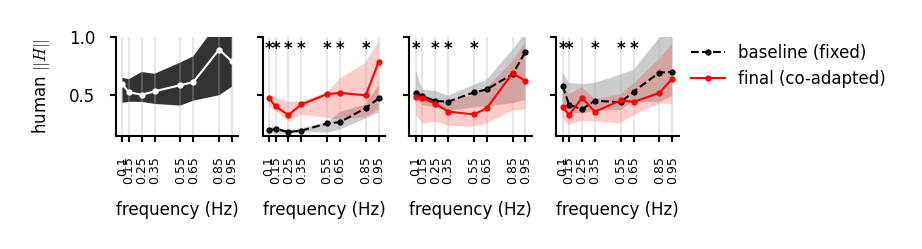

In [7]:
# human H magnitude: H at I* (fixed) vs. co-adapted (final 3 trials)
xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
xlim = (0.05, 1.0)
fig,axs = plt.subplots(1,4,sharex=True,sharey=True,figsize=(3,0.75),dpi=300)

for cond, condition in enumerate(condition_orders):
    H_last_3_trials = np.mean(np.abs(Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # last 3 adaptive trials
    selected = np.concatenate((Hs[:,cond,:3][:,:,IX], Hs[:,cond,-3:][:,:,IX]), axis=1) # 6 fixed trials
    H_I_star = np.mean(np.abs(selected),axis = 1) # H at I*

    ax = axs[cond+1]
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_I_star, axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'black',label = 'baseline (fixed)',linestyle='--')
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'black',edgecolor='none')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'red', label = 'final (co-adapted)')
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red',edgecolor='none')

    for f in range(len(freqs)):
        data1 = H_last_3_trials[:,f] # average across trials
        data2 = H_I_star[:,f] # average across trials
        statistic, p_value = stats.ttest_rel(data1, data2)
        print(f" {freqs[f]:.3f}, p-value: {p_value:.3f}")

        if p_value < 0.05:
            ax.text(freqs[f], 0.9, '*', ha='center', va='center', fontweight='bold')

    print('\n')

ax = axs[0]
H_base_trials = np.mean(np.abs(Hs_base[:,:,IX]),axis = 1)
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_base_trials, axis = 0)
ax.plot(freqs,quantile50,'-',marker = '.',color = 'white')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.8,color = 'black',edgecolor='none')

for j in range(4):
    ax = axs[j]
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks,rotation=90, fontsize=MINI_SIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid('on',axis='x',zorder=-1,alpha = 0.3)
    ax.set_ylim(0.15,1)
    ax.set_xlabel('frequency (Hz)')

yticks_shared = [0.5,1.0]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0.5,1.0])
axs[0].set_ylabel(r'human $||H||$')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)
axs[-1].legend(bbox_to_anchor=(1.05, 1), borderaxespad=0., frameon=False)
plt.tight_layout()
plt.show()